In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

In [3]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
layout_info = pd.read_csv('../data/layout_info.csv')

print(f"학습 데이터 크기: {train.shape}")
print(f"테스트 데이터 크기: {test.shape}")
print(f"레이아웃 정보 크기: {layout_info.shape}")

학습 데이터 크기: (250000, 94)
테스트 데이터 크기: (50000, 93)
레이아웃 정보 크기: (300, 15)


In [4]:
train.describe().round(3)

,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,robot_active,robot_idle,robot_charging,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
count,220436.000,220076.000,220377.000,220246.000,220384.000,220549.000,220301.000,250000.000,250000.000,250000.000,...,220358.000,220457.000,220273.000,220448.000,220544.000,220532.000,220595.000,220448.000,220466.000,220230.000
mean,94.586,108.276,3.473,0.112,0.179,0.095,0.425,13.379,25.813,6.129,...,6.895,0.215,4.928,0.126,14.019,9.291,87.078,0.093,5.005,96.430
std,77.084,105.558,2.190,0.108,0.111,0.081,0.193,11.449,22.687,12.434,...,2.247,0.107,2.213,0.059,7.104,4.792,6.328,0.042,3.034,2.127
min,0.000,0.000,1.000,0.000,0.000,0.000,0.100,0.000,0.000,0.000,...,2.000,0.000,0.500,0.000,0.000,1.000,70.000,0.000,0.000,90.000
25%,29.000,37.000,1.460,0.023,0.100,0.026,0.268,4.000,2.000,0.000,...,5.080,0.130,3.260,0.079,8.600,5.430,82.300,0.061,2.510,94.770
50%,78.000,73.000,2.840,0.081,0.176,0.083,0.399,10.000,23.000,0.000,...,6.890,0.215,4.910,0.126,13.900,9.300,87.100,0.092,5.020,96.450
75%,142.000,141.000,4.980,0.180,0.255,0.144,0.557,19.000,45.000,6.000,...,8.710,0.299,6.450,0.173,18.800,13.080,91.900,0.124,7.470,98.150
max,477.000,500.000,15.000,1.000,1.000,0.500,0.900,79.000,80.000,80.000,...,12.000,0.500,10.000,0.300,30.000,24.000,100.000,0.200,15.000,100.000


In [3]:
train.head()

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02


In [6]:
layout_info.head()

,layout_id,layout_type,aisle_width_avg,intersection_count,one_way_ratio,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,WH_001,narrow,2.08,34.0,0.3874,9.0,8.0,0.8078,0.5867,21,20,3384,9.4,36,5
1,WH_002,grid,3.70,16.0,0.0054,9.0,11.0,0.7339,0.4390,57,26,8311,8.1,12,2
2,WH_003,grid,2.54,52.0,0.0229,5.0,3.0,0.5498,0.3708,63,39,9465,7.2,81,2
3,WH_004,hybrid,3.37,35.0,0.4836,5.0,10.0,0.4821,0.5661,100,40,7918,12.7,26,5
4,WH_005,grid,3.68,48.0,0.0494,8.0,13.0,0.6740,0.9970,50,33,5905,5.6,84,9


In [3]:
TARGET = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

feature_cols = [c for c in train.columns if c not in ID_COLS + [TARGET]]
print(f"피처 수: {len(feature_cols)}")

피처 수: 90


In [11]:
train.head(100)

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TRAIN_000095,WH_151,SC_06881,161.0,66.0,1.36,0.0932,0.1491,0.0248,0.6574,...,7.10,0.4359,8.05,0.1882,25.3,11.36,84.7,0.0861,0.41,95.74
96,TRAIN_000096,WH_151,SC_06881,176.0,56.0,1.39,0.0852,0.1932,0.0284,NaN,...,8.67,0.4195,6.97,0.1304,24.0,11.60,84.9,0.1070,NaN,95.59
97,TRAIN_000097,WH_151,SC_06881,171.0,79.0,1.40,NaN,NaN,0.0234,0.6574,...,7.06,0.4511,6.85,0.1765,NaN,NaN,76.6,NaN,1.40,94.01
98,TRAIN_000098,WH_151,SC_06881,93.0,44.0,NaN,0.0645,NaN,0.0323,0.6574,...,6.78,0.4292,7.26,0.1558,16.0,NaN,85.1,0.0930,3.29,96.35


In [12]:
train.columns

Index(['ID', 'layout_id', 'scenario_id', 'order_inflow_15m', 'unique_sku_15m',
       'avg_items_per_order', 'urgent_order_ratio', 'heavy_item_ratio',
       'cold_chain_ratio', 'sku_concentration', 'robot_active', 'robot_idle',
       'robot_charging', 'robot_utilization', 'avg_trip_distance',
       'task_reassign_15m', 'battery_mean', 'battery_std', 'low_battery_ratio',
       'charge_queue_length', 'avg_charge_wait', 'congestion_score',
       'max_zone_density', 'blocked_path_15m', 'near_collision_15m',
       'fault_count_15m', 'avg_recovery_time', 'replenishment_overlap',
       'pack_utilization', 'manual_override_ratio',
       'avg_delay_minutes_next_30m', 'warehouse_temp_avg', 'humidity_pct',
       'day_of_week', 'external_temp_c', 'wind_speed_kmh', 'precipitation_mm',
       'lighting_level_lux', 'ambient_noise_db', 'floor_vibration_idx',
       'return_order_ratio', 'air_quality_idx', 'co2_level_ppm',
       'hvac_power_kw', 'wms_response_time_ms', 'scanner_error_rate',
 

In [19]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 94 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          250000 non-null  str    
 1   layout_id                   250000 non-null  str    
 2   scenario_id                 250000 non-null  str    
 3   order_inflow_15m            220436 non-null  float64
 4   unique_sku_15m              220076 non-null  float64
 5   avg_items_per_order         220377 non-null  float64
 6   urgent_order_ratio          220246 non-null  float64
 7   heavy_item_ratio            220384 non-null  float64
 8   cold_chain_ratio            220549 non-null  float64
 9   sku_concentration           220301 non-null  float64
 10  robot_active                250000 non-null  int64  
 11  robot_idle                  250000 non-null  int64  
 12  robot_charging              250000 non-null  int64  
 13  robot_utilization        

In [14]:
train.describe()

,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,robot_active,robot_idle,robot_charging,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
count,220436.000000,220076.000000,220377.000000,220246.000000,220384.000000,220549.000000,220301.000000,250000.000000,250000.000000,250000.000000,...,220358.000000,220457.000000,220273.000000,220448.000000,220544.000000,220532.000000,220595.000000,220448.000000,220466.000000,220230.000000
mean,94.585662,108.275673,3.473318,0.112411,0.179021,0.094962,0.425110,13.379388,25.813408,6.128704,...,6.895087,0.214840,4.927512,0.126086,14.018698,9.291452,87.077735,0.092604,5.005130,96.429794
std,77.083546,105.558290,2.190259,0.108145,0.111210,0.081449,0.192997,11.449100,22.687023,12.433735,...,2.246697,0.106773,2.213228,0.059362,7.103918,4.791728,6.328054,0.041663,3.034295,2.127183
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,...,2.000000,0.000000,0.500000,0.000000,0.000000,1.000000,70.000000,0.000000,0.000000,90.000000
25%,29.000000,37.000000,1.460000,0.023300,0.100000,0.026000,0.268500,4.000000,2.000000,0.000000,...,5.080000,0.130400,3.260000,0.079200,8.600000,5.430000,82.300000,0.060600,2.510000,94.770000
50%,78.000000,73.000000,2.840000,0.081100,0.176500,0.083300,0.399300,10.000000,23.000000,0.000000,...,6.890000,0.214600,4.910000,0.126300,13.900000,9.300000,87.100000,0.092200,5.020000,96.450000
75%,142.000000,141.000000,4.980000,0.179900,0.254600,0.144400,0.557000,19.000000,45.000000,6.000000,...,8.710000,0.298800,6.450000,0.172700,18.800000,13.080000,91.900000,0.124000,7.470000,98.150000
max,477.000000,500.000000,15.000000,1.000000,1.000000,0.500000,0.900000,79.000000,80.000000,80.000000,...,12.000000,0.500000,10.000000,0.300000,30.000000,24.000000,100.000000,0.200000,15.000000,100.000000


In [15]:
train.isnull().sum()

ID                              0
layout_id                       0
scenario_id                     0
order_inflow_15m            29564
unique_sku_15m              29924
                            ...  
dock_to_stock_hours         29468
kpi_otd_pct                 29405
backorder_ratio             29552
shift_handover_delay_min    29534
sort_accuracy_pct           29770
Length: 94, dtype: int64

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(train)):
    print(f"── Fold {fold + 1} ──")
    X_tr = train.loc[tr_idx, feature_cols]
    y_tr = train.loc[tr_idx, TARGET]
    X_val = train.loc[val_idx, feature_cols]
    y_val = train.loc[val_idx, TARGET]

    model = LGBMRegressor(
        n_estimators=1000, learning_rate=0.05, max_depth=7,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
    )

    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(test[feature_cols]) / 5

── Fold 1 ──
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 494.261
[200]	valid_0's l2: 474.567
[300]	valid_0's l2: 460.88
[400]	valid_0's l2: 450.216
[500]	valid_0's l2: 442.736
[600]	valid_0's l2: 436.378
[700]	valid_0's l2: 430.24
[800]	valid_0's l2: 425.243
[900]	valid_0's l2: 421.239
[1000]	valid_0's l2: 417.524
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 417.524
── Fold 2 ──
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 503.98
[200]	valid_0's l2: 485.04
[300]	valid_0's l2: 473.31
[400]	valid_0's l2: 464.703
[500]	valid_0's l2: 458.153
[600]	valid_0's l2: 451.458
[700]	valid_0's l2: 445.839
[800]	valid_0's l2: 440.982
[900]	valid_0's l2: 436.954
[1000]	valid_0's l2: 433.272
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 433.272
── Fold 3 ──
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 468.227
[200]	valid_0's l2: 448.275
[300]	valid

In [9]:
oof_mae = mean_absolute_error(train[TARGET], oof_preds)
print(f"OOF MAE: {oof_mae:.4f}")

OOF MAE: 9.2405


In [10]:
submission = pd.DataFrame({'ID': test['ID'], TARGET: test_preds})
submission.to_csv('./submission.csv', index=False)
print("submission.csv 저장 완료.")

submission.csv 저장 완료.


In [7]:
df = train.merge(layout_info, on='layout_id', how='left')

In [8]:
df.head()

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,pack_station_count,charger_count,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,10.0,5.0,0.4276,0.2536,30,7,5961,6.0,56,4


In [9]:
df.shape

(250000, 108)

In [10]:
df['layout_type'] = df['layout_type'].astype('category')

In [11]:
df.isnull().sum().sort_values(ascending=False)

avg_recovery_time        32529
congestion_score         32250
avg_charge_wait          30696
battery_mean             30320
charge_efficiency_pct    30052
                         ...  
robot_charging               0
robot_idle                   0
robot_active                 0
scenario_id                  0
emergency_exit_count         0
Length: 108, dtype: int64

In [12]:
# 1. merge
df = train.merge(layout_info, on='layout_id', how='left')

# 2. 결측치 flag
df['is_null_sort_accuracy'] = df['sort_accuracy_pct'].isnull().astype(int)

# 3. 결측치 처리
df.fillna(df.median(numeric_only=True), inplace=True)

# 4. 이상치 클리핑
for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# 5. 로그 변환 (중요 변수)
import numpy as np
df['order_log'] = np.log1p(df['order_inflow_15m'])

In [13]:
df.head()

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,layout_compactness,zone_dispersion,robot_total,building_age_years,floor_area_sqm,ceiling_height_m,fire_sprinkler_count,emergency_exit_count,is_null_sort_accuracy,order_log
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,0.4276,0.2536,30,7,5961,6.0,56,4,0,3.951244
1,TRAIN_000001,WH_136,SC_07598,78.0,93.0,2.55,0.0597,0.1765,0.0149,0.3993,...,0.4276,0.2536,30,7,5961,6.0,56,4,0,4.369448
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,0.4276,0.2536,30,7,5961,6.0,56,4,0,4.532599
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,0.1765,0.0390,0.3063,...,0.4276,0.2536,30,7,5961,6.0,56,4,0,4.356709
4,TRAIN_000004,WH_136,SC_07598,78.0,122.0,3.12,0.0667,0.3333,0.0833,0.3063,...,0.4276,0.2536,30,7,5961,6.0,56,4,0,4.369448


In [14]:
# 통로 폭 (좁음 vs 넓음)
df['aisle_group'] = pd.qcut(df['aisle_width_avg'], 2, labels=['narrow', 'wide'])

# 주문량 (적음 vs 많음)
df['order_group'] = pd.qcut(df['order_inflow_15m'], 2, labels=['low', 'high'])

In [15]:
df['group'] = df['aisle_group'].astype(str) + '_' + df['order_group'].astype(str)

In [16]:
df.groupby('group')['avg_delay_minutes_next_30m'].mean()

group
narrow_high    24.102771
narrow_low     11.460451
wide_high      23.554138
wide_low       10.900656
Name: avg_delay_minutes_next_30m, dtype: float64

<Axes: xlabel='aisle_group', ylabel='avg_delay_minutes_next_30m'>

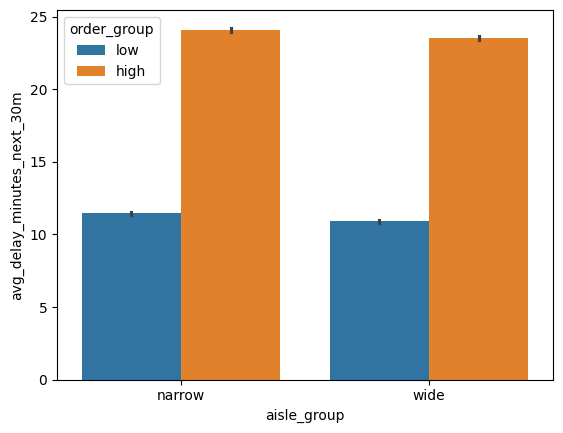

In [25]:
import seaborn as sns

sns.barplot(
    data=df,
    x='aisle_group',
    y='avg_delay_minutes_next_30m',
    hue='order_group'
)

In [20]:
df['interaction'] = df['aisle_width_avg'] * df['order_inflow_15m']

In [23]:
import statsmodels.api as sm

X = df[['aisle_width_avg', 'order_inflow_15m', 'interaction']]
X = sm.add_constant(X)

y = df['avg_delay_minutes_next_30m']

model = sm.OLS(y, X).fit()
print(model.summary())

                                OLS Regression Results                                
Dep. Variable:     avg_delay_minutes_next_30m   R-squared:                       0.186
Model:                                    OLS   Adj. R-squared:                  0.186
Method:                         Least Squares   F-statistic:                 1.900e+04
Date:                        Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                                12:00:34   Log-Likelihood:            -1.0353e+06
No. Observations:                      250000   AIC:                         2.071e+06
Df Residuals:                          249996   BIC:                         2.071e+06
Df Model:                                   3                                         
Covariance Type:                    nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

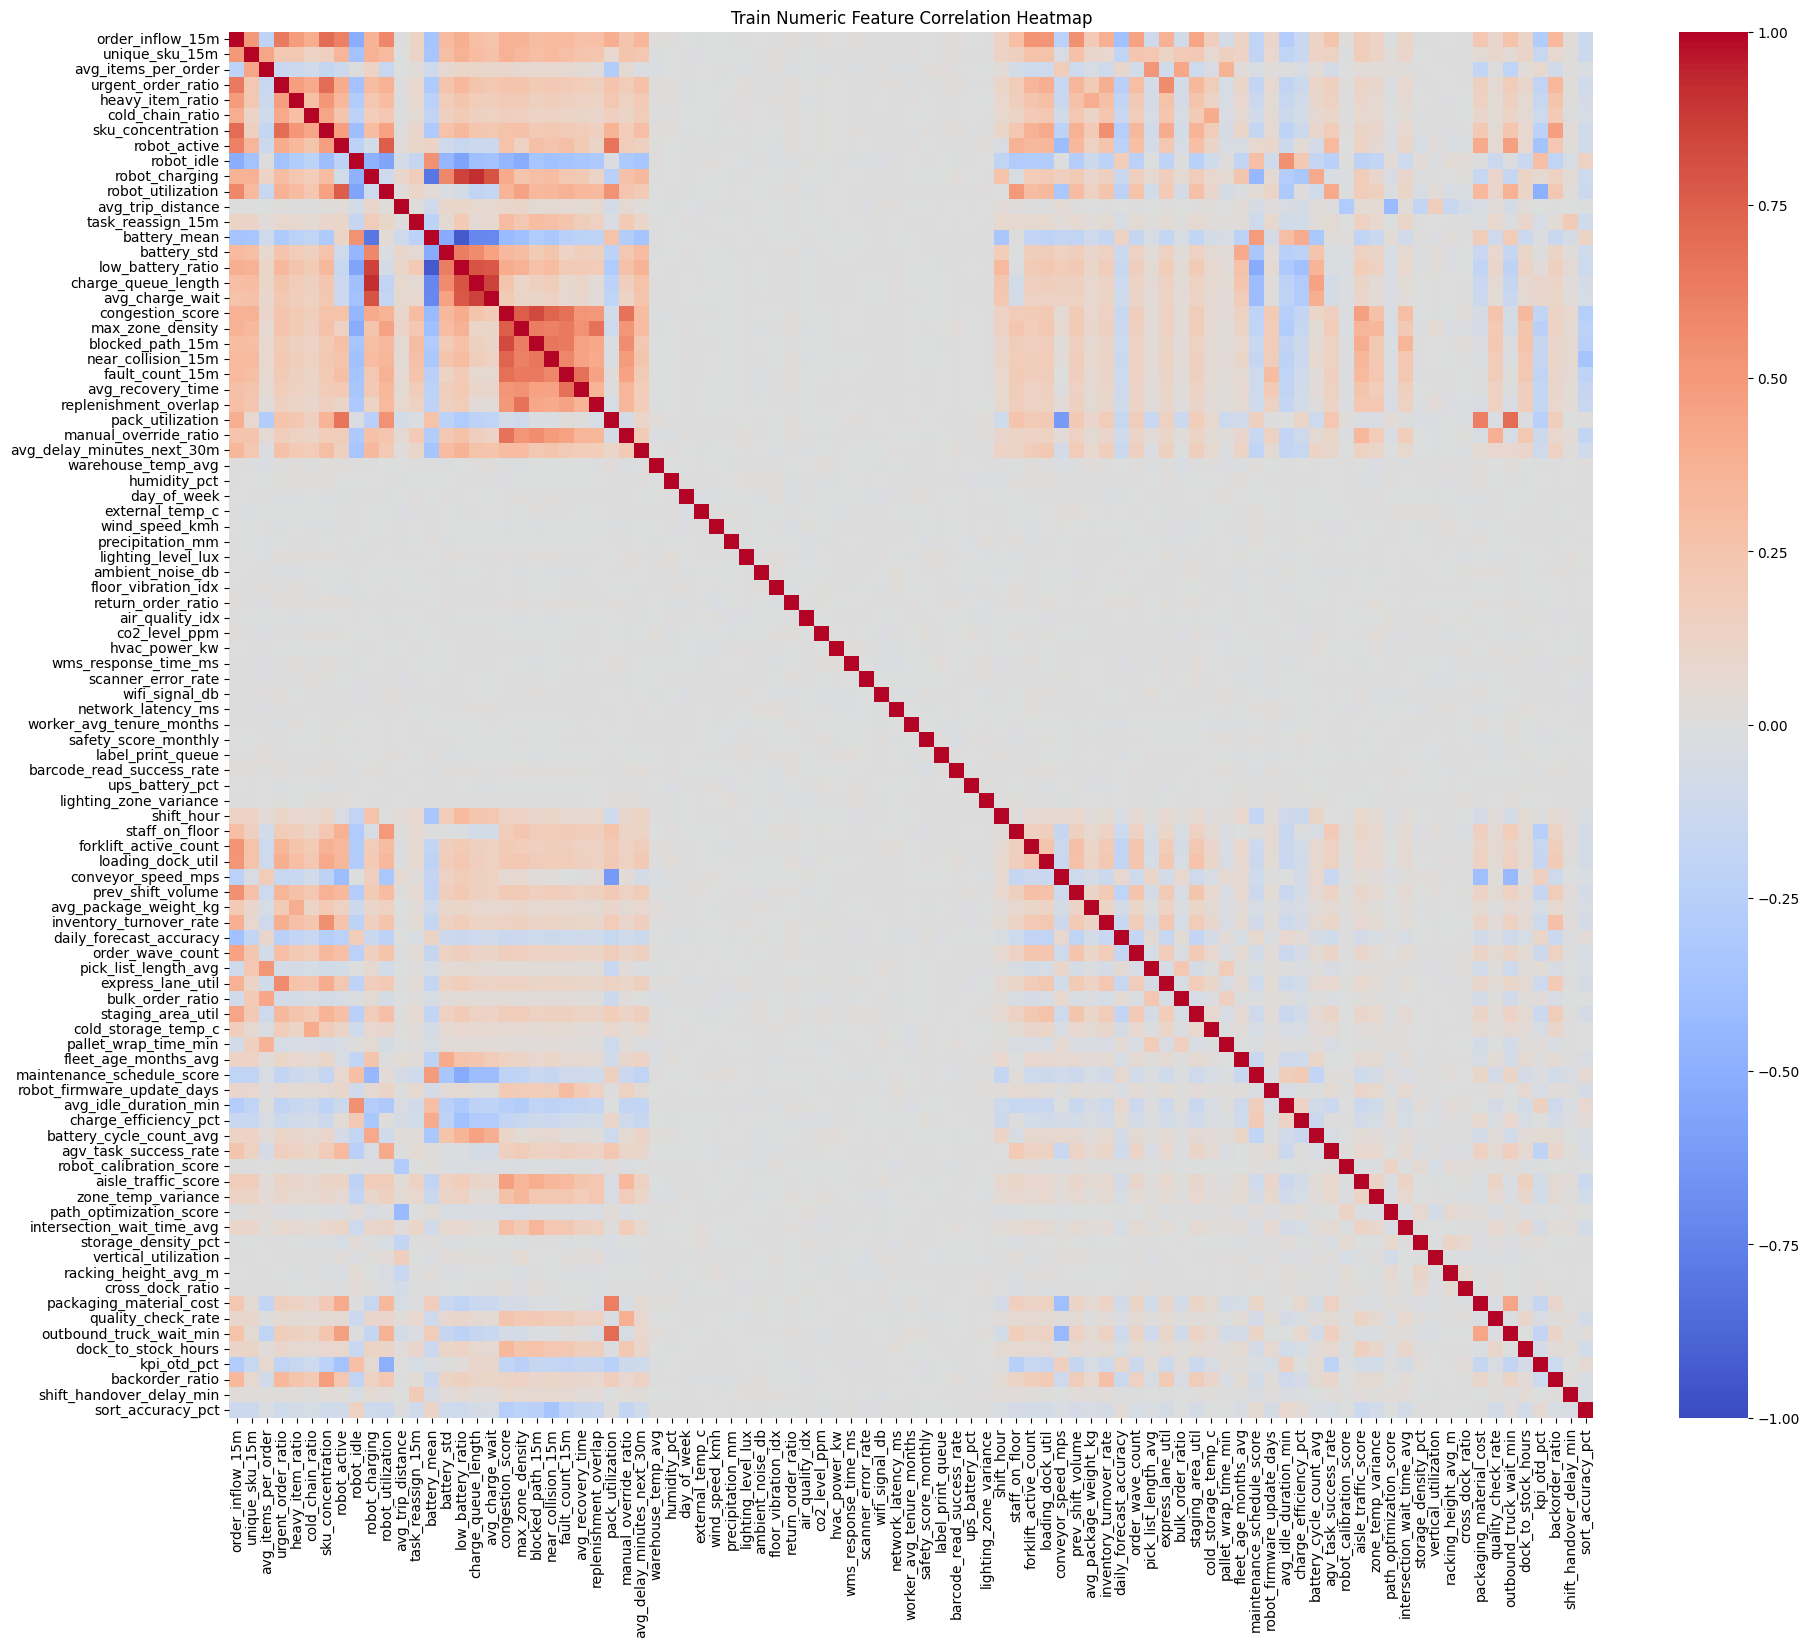

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

train = pd.read_csv('../data/train.csv')

# 수치형만
num_df = train.select_dtypes(include='number')

# 상관계수 행렬
corr = num_df.corr()

# 히트맵 (너무 크니까 figsize 크게)
plt.figure(figsize=(22, 18))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Train Numeric Feature Correlation Heatmap')
plt.show()


In [27]:
target_col = 'avg_delay_minutes_next_30m'
target_corr = (
    corr[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print(target_corr.head(20))


low_battery_ratio             0.366073
battery_mean                 -0.358886
robot_idle                   -0.349311
order_inflow_15m              0.341754
robot_charging                0.320406
max_zone_density              0.310816
battery_std                   0.308313
congestion_score              0.300357
sku_concentration             0.291888
urgent_order_ratio            0.271079
charge_queue_length           0.261425
avg_charge_wait               0.251458
near_collision_15m            0.242848
unique_sku_15m                0.229013
blocked_path_15m              0.220499
loading_dock_util             0.213132
robot_utilization             0.210818
heavy_item_ratio              0.210314
fault_count_15m               0.202893
maintenance_schedule_score   -0.196758
Name: avg_delay_minutes_next_30m, dtype: float64
